# Fig4e-f: 3D liver cell reconstruction based EMCellFound model

Information:

Dataset ID: jrc_mus-liver-6

Source: HHMI Janelia OpenOrganelle

Sample: Liver tissue from a 10-week-old male leptin-deficient
B6.Cg-Lepob/J (ob/ob) mouse on a C57BL/6J genetic background.

Native voxel size: 8 × 8 × 8 nm (z, y, x).

Native array shape: 8,501 × 8,050 × 8,000 voxels (z, y, x).

Physical extent: 68,008 × 64,400 × 64,000 nm (z, y, x).

This experiment evaluated sparse-annotation adaptation within a single
specimen, volume, and acquisition session; it was not designed as an
evaluation of cross-specimen or cross-volume generalization.

We randomly selected three images extracted from the xy, xz, and yz planes for training, three for validation, and three for testing.

- Training slices: x=5000, y=2000, z=3000
- Validation slices: x=7500, y=6500, z=4000
- Testing slices: x=4000, y=5000, z=6000


train datset
'''
jrc_mus_liver-6_part_5000
jrc_mus_liver-6_part_y_2000
jrc_mus_liver-6_part_z_3000
'''

val dataset
'''
jrc_mus_liver-6_part_7500
jrc_mus_liver-6_part_y_6500
jrc_mus_liver-6_part_z_4000
'''

test dataset
'''
jrc_mus_liver-6_part_z_6000
jrc_mus_liver-6_part_4000
jrc_mus_liver-6_part_y_5000
'''


The organelles to be segmented.
0 background: [0, 0, 0]
1 ER: [128, 128, 0]
2 mito: [128, 0, 128]
3 LD: [123, 95, 213]
4 Nu: [14, 159, 38]


In [ ]:
from mmengine import Config
import pathlib
import sys
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")

# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))


cfg_path = BASE_DIR / 'src'/ 'thirdParty' / 'mmsegmentation' /"configs" / "Liver_seg" / "ViT_Finetune.py"
model_path = BASE_DIR / "models" / "MAE_backbone_mmbackend.pth"
data_root = BASE_DIR / "datasets_temp" / "Liver_3DReconstruct"
work_dir = BASE_DIR / "save_logs" / "LiverSeg3DReconstruct"

# validate the existence of the config and model files
print(f"BASE_DIR: {BASE_DIR}")
print(f"cfg exists: {cfg_path.exists()}")
print(f"model exists: {model_path.exists()}")
assert cfg_path.exists(), f"Config not found: {cfg_path}"
assert model_path.exists(), f"Checkpoint not found: {model_path}"


cfg = Config.fromfile(cfg_path)
# set the path to the pretrained model from the huggingface hub, 
# you can change it to your own path if you have downloaded the model to a different location
# models are named as "xxxx_backbone_mmbackend.pth" in the huggingface hub
cfg.load_from = str(model_path)
# set the path to the dataset where the dataset is unzipped, 
# you can change it to your own path if you have downloaded the dataset to a different location
cfg.data_root = str(data_root)


from configs.register_models.runtime import set_data_root
set_data_root(cfg, cfg.data_root)
# set the working directory to save logs and models
cfg.work_dir = str(work_dir)

# check the batch size of the training dataloader, if it is too large, you can reduce it to avoid out of memory error
cfg.train_dataloader.batch_size = 8

from mmengine.runner import Runner
runner = Runner.from_cfg(cfg)
# start training
runner.train()

In [ ]:
import pathlib
import sys
import torch
import cv2
import matplotlib.pyplot as plt
from mmengine import Config
from mmseg.apis import init_model, inference_model, show_result_pyplot
from configs.register_models.runtime import *

# ===================== Base Path Dir=====================
# BASE_DIR = pathlib.Path(r"Fill your absolute path").resolve()
BASE_DIR = pathlib.Path.cwd().resolve().parent

sys.path.insert(0, str(BASE_DIR))

cfg_path = str(BASE_DIR / "save_logs" / "LiverSeg3DReconstruct" / "ViT_Finetune.py")
# get the path to the best checkpoint,
# using search to find the best checkpoint in the work_dir
for file in (BASE_DIR / "save_logs" / "LiverSeg3DReconstruct").glob("best_mIoU_iter_*.pth"):
    ckpt_path = str(file)
    break
# =================================================================

# 1. load the config and model
cfg = Config.fromfile(cfg_path)
# when inference, 
# we can set the mode to "slide" and specify the crop size and stride 
# for sliding window inference
cfg.test_cfg.mode = "slide"
cfg.test_cfg.crop_size = (1024,1024)
cfg.test_cfg.stride = (800, 800)

# 加载模型到GPU，没有cuda就写 device="cpu"
model = init_model(cfg, ckpt_path, device="cuda:0")
print("✅ Model loaded successfully!")
print(f"Classes info: {model.dataset_meta['classes']}")

# 2. inference a single image
img_path = str(BASE_DIR / "datasets_temp" / "Liver_3DReconstruct" 
               / "image" / "jrc_mus_liver-6_part_z_6000.tif")
img = cv2.imread(img_path)

with torch.no_grad():
    result = inference_model(model, img)

# visualize the result
vis_img = show_result_pyplot(model, img, result, opacity=0.5, show=False)

plt.figure(figsize=(10,10))
plt.imshow(vis_img)
plt.axis('off')
plt.show()

Since LD and NU can be very large, small sliding windows are unable to fully cover these structures, resulting in holes within the segmented regions.

Two strategies can be adopted to address this issue: training separate models for small organelles (ER and mitochondria) and large 
structures (NU and LD), or applying a hole-filling post-processing algorithm.

We use the latter strategy in this demo.

See below:

In [ ]:
from mmseg.apis import fill_holes_for_classes
pred_mask_np = result.pred_sem_seg.data[0].cpu().numpy()
# fill holes for classes 3 and 4 (too large Nu and LD) in the segmentation mask
pred_mask_filled_np = fill_holes_for_classes(pred_mask_np, target_classes=[3,4])

# 回填回SegDataSample用于可视化
result.pred_sem_seg.data[0] = torch.from_numpy(pred_mask_filled_np)
# 可视化叠加图
vis_img = show_result_pyplot(model, img, result, opacity=0.5, show=False)
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(vis_img)
plt.title("Mask after fill holes (class3,4)")
plt.axis("off")
plt.show()

We have successfully trained a 2D segmentation model for ER, mitochondria, nucleus (Nu), and lipid droplets (LD).

 To reconstruct the 3D structure of the volumetric dataset, we perform inference slice-by-slice along the z-axis of the volume to obtain 2D segmentation predictions for each slice.

These 2D slice masks can then be imported into Amira, Avizo, or Arivis for 3D visualization.

Full dataset can be downloaded from: https://www.ebi.ac.uk/empiar/EMPIAR-10791/
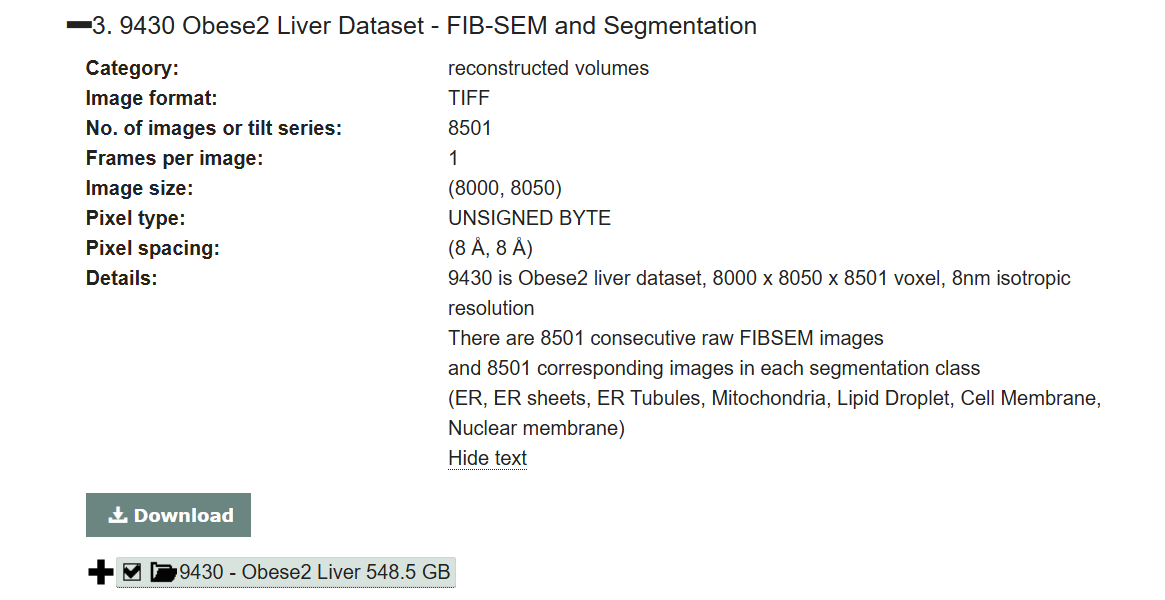


In this demo, we use part of this dataset.

Partition volume (1998x2136x4250) of the original size.

The data (12GB) can be download from huggingface link (https://huggingface.co/datasets/Zeyu0102/Obese2_Liver_6_Dataset)

In [ ]:
import os
from huggingface_hub import snapshot_download

local_dir = "datasets_temp/Obese2_Liver_6_Dataset"
snapshot_download(repo_id="Zeyu0102/Obese2_Liver_6_Dataset", repo_type="dataset",
                  local_dir=local_dir,
                  local_dir_use_symlinks=False, 
                  resume_download=True,
                  )

print("Obese2_Liver_6_Dataset 3D Reconstruction Dataset downloaded successfully.")

#### 2D slice inference for 3D reconstruction

In [ ]:
import pathlib
import sys
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")
# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))


from mmengine import Config
from mmseg.apis import init_model, inference_model, fill_holes_for_classes
from configs.register_models.runtime import *
# ===================== Base Path Dir=====================
BASE_DIR = pathlib.Path.cwd().resolve().parent

sys.path.insert(0, str(BASE_DIR))

cfg_path = str(BASE_DIR / "save_logs" / "LiverSeg3DReconstruct" / "ViT_Finetune.py")
# get the path to the best checkpoint,
# using search to find the best checkpoint in the work_dir
for file in (BASE_DIR / "save_logs" / "LiverSeg3DReconstruct").glob("best_mIoU_iter_*.pth"):
    ckpt_path = str(file)
    break
# =================================================================


# 1. load the config and model
cfg = Config.fromfile(cfg_path)
cfg.test_cfg.crop_size = (512, 512)
cfg.test_cfg.stride = (400, 400)
# load the model to GPU, if no cuda, use device="cpu"
model = init_model(cfg, ckpt_path, device="cuda:0")
print("✅ Model loaded successfully!")
print(f"Classes info: {model.dataset_meta['classes']}")
palette = np.array(model.dataset_meta['palette'], dtype=np.uint8)

# 2. inference from folder of images
folder_path = BASE_DIR / "demo" / "datasets_temp" / "Obese2_Liver_6_Dataset"
result_dir = folder_path / "results"
result_dir.mkdir(exist_ok=True)

img_ext = (".png",)
for img_file in os.listdir(folder_path):
    if img_file.lower().endswith(img_ext):
        img_path = str(folder_path / img_file)
        save_path = str(result_dir / img_file)
        print(f"Processing: {img_file}")

        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Warning: Cannot read image {img_file}, skip.")
            continue

        with torch.no_grad():
            result = inference_model(model, img)

        # Extract raw prediction mask
        pred_mask_np = result.pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)
        # ========== postprocess to fill the hole ==========
        pred_mask_filled = fill_holes_for_classes(pred_mask_np, target_classes=[3, 4])

        # -------- get palatte in the label--------
        # palette shape: (num_classes, 3) RGB
        pred_rgb = palette[pred_mask_filled]
        pred_bgr = cv2.cvtColor(pred_rgb, cv2.COLOR_RGB2BGR)

        # save the color segmentation mask
        _ = cv2.imwrite(save_path, pred_bgr)

        # # Optional: visualize the result
        # paste the label to the original image for visualization
        vis_img = cv2.addWeighted(img, 0.5, pred_bgr, 0.5, 0)
        _ = cv2.imwrite(str(result_dir / f"vis_{img_file}"), vis_img)
         
print(f"\n✅ Inference completed for all images in {folder_path}.\nResults saved to {result_dir}")